In [49]:
from sklearn.datasets import make_moons

In [50]:
moons_data, moons_label = make_moons(n_samples=10000, noise=0.4)

In [51]:
from sklearn.model_selection import train_test_split


In [52]:
X_train, X_test, y_train, y_test = train_test_split(moons_data, moons_label, test_size=0.2, random_state=42)

In [53]:
X_train.shape


(8000, 2)

In [54]:
y_train.shape

(8000,)

In [55]:
# Printing first Features
X_train[:5]

array([[-0.39560371,  1.02767261],
       [ 0.50963879, -1.0469636 ],
       [ 0.89252309,  1.21915839],
       [-0.26115057,  0.77491891],
       [ 2.12925691, -0.15274338]])

In [56]:
# Printing first 5 Labels (Classifications)
y_train[:5]

array([0, 1, 0, 1, 1])

In [57]:
# Import Plotting library
import matplotlib.pyplot as plt



In [58]:
slice_of_array = X_train[:,0]

slice_of_array.shape

(8000,)

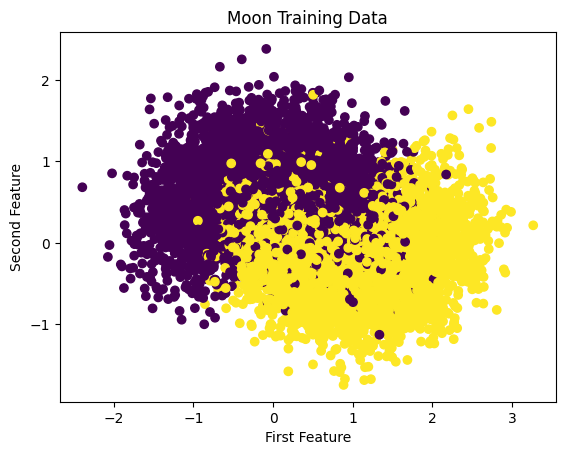

In [59]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.xlabel("First Feature")
plt.ylabel("Second Feature")
plt.title("Moon Training Data")
plt.show()

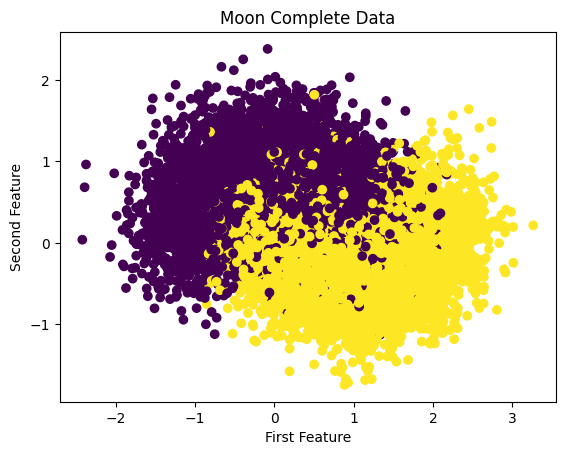

In [60]:
plt.scatter(moons_data[:, 0], moons_data[:, 1], c=moons_label)
plt.xlabel("First Feature")
plt.ylabel("Second Feature")
plt.title("Moon Complete Data")
plt.show()

In [61]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

In [62]:
param_grid = {
    'min_samples_leaf': list(range(2, 10))
    , 'max_leaf_nodes': list(range(2, 100))
    , 'max_depth': list(range(1,7))
}

dec_tree_clf = DecisionTreeClassifier()

In [63]:
grid_search_cv = GridSearchCV(dec_tree_clf, param_grid=param_grid, cv=3, n_jobs=4)

In [64]:
grid_search_cv.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [1, 2, ...], 'max_leaf_nodes': [2, 3, ...], 'min_samples_leaf': [2, 3, ...]}"
,scoring,None
,n_jobs,4
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [65]:
grid_search_cv.best_params_

{'max_depth': 2, 'max_leaf_nodes': 4, 'min_samples_leaf': 2}

In [66]:
best_estimator_dclf = grid_search_cv.best_estimator_

In [67]:
best_estimator_dclf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,4
,min_impurity_decrease,0.0
,class_weight,None


In [68]:
y_predict = best_estimator_dclf.predict(X_test)

In [69]:
from sklearn.metrics import f1_score


In [70]:
f1_score_reached = f1_score(y_test, y_predict)

In [71]:
f1_score_reached

0.8604878048780488

In [72]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predict) # Return Value will be printed in notebook


0.857

In [ ]:
# Exercise 8
# manually growing a Random Forest Classifier

# a) 1000 Untermengen des Datensatzes mit jeweils 100 zufälligen Datenpunkten

from sklearn.model_selection import ShuffleSplit

number_of_datasets = 1000
number_of_elements = 100

mini_sets = []

rs = ShuffleSplit(n_splits=number_of_datasets, test_size=len(X_train) - number_of_elements,
                  random_state=42)

for mini_train_index, mini_test_index in rs.split(X_train):
    X_mini_train = X_train[mini_train_index]
    y_mini_train = y_train[mini_train_index]
    mini_sets.append((X_mini_train, y_mini_train))

In [77]:
print(mini_sets[0][1])

[0 0 0 0 1 0 1 0 1 1 0 1 0 1 0 0 0 0 1 0 1 1 1 0 1 0 1 1 0 1 0 0 0 0 0 0 1
 1 1 1 1 0 1 0 1 1 0 1 0 0 1 1 1 0 1 1 1 0 1 0 0 0 0 1 1 1 0 1 1 0 0 1 0 1
 0 0 0 0 0 1 1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 1 0 1 0 0]


In [ ]:
# b) Trainieren eines Entscheidungsbaumes Je Datenset

from sklearn.base import clone
import numpy as np

forest = []

scores = []

# Cloning best estimator
for i in range(number_of_datasets):
    estimator = clone(best_estimator_dclf)
    forest.append(estimator)

for i, estimator_record in enumerate(forest):
    train_X = mini_sets[i][0]
    train_y = mini_sets[i][1]

    estimator_record.fit(train_X, train_y)

    y_pred_est_record = estimator_record.predict(X_test)
    f1_score_estimator_record = f1_score(y_test, y_pred_est_record)

    scores.append(f1_score_estimator_record)


print(scores)
print(np.mean(scores))

[0.8645533141210374, 0.8567208271787297, 0.8635014836795252, 0.8228255867464335, 0.8544688816097332, 0.816452896948253, 0.8466135458167331, 0.821300563236047, 0.7880794701986755, 0.763086886130599, 0.8557457212713936, 0.7155742633794347, 0.7540086038326164, 0.8581560283687943, 0.8313767342582711, 0.8335078534031414, 0.7959183673469388, 0.8477822580645161, 0.7874526771227691, 0.8539865513928915, 0.807542983915696, 0.8138414367060884, 0.8206572769953052, 0.7722007722007722, 0.7937365010799136, 0.5894308943089431, 0.7633401221995927, 0.852589641434263, 0.8328940432261466, 0.8448540706605223, 0.79312257348863, 0.8168137000518941, 0.8479501816294759, 0.8497970230040596, 0.8082262210796916, 0.8328940432261466, 0.799552071668533, 0.7892134831460674, 0.8523249872253449, 0.7092337917485265, 0.8512609366958311, 0.8221709006928406, 0.7881401617250674, 0.8544243577545195, 0.8249106687085248, 0.8271604938271605, 0.8572815533980582, 0.7296137339055794, 0.8266395526182003, 0.8182273410115173, 0.84604

In [ ]:
# c) Mehrheitsvoting implementieren. Nur die häufigste Vorhersage behalten

# leeres Prediction Array 1000 x mit der Feature Länge
Y_pred = np.empty([number_of_datasets, len(X_test)], dtype=np.uint8)

print(Y_pred.shape)

(1000, 2000)


In [89]:
# Für jeden Baum ein Prediction Array erstellen
for tree_index, tree in enumerate(forest):
    Y_pred[tree_index] = tree.predict(X_test)

In [91]:
print(Y_pred.shape)

(1000, 2000)


In [ ]:
from scipy.stats import mode

# mode returned ein array mit dem häufigsten Wert im ndarray.
# y_pred hält 1000 Arrays mit der Länge 2000. mode evaluiert welcher Wert innerhalb dieser 1000 Array je axis=1 am häufigsten vorkommt
# der häufigste Wert wird dann in das Ziel Array übernommen

y_pred_majority_votes, n_votes = mode(Y_pred, axis=0)

In [92]:
print(y_pred_majority_votes.shape)

(2000,)


In [88]:
print(y_pred_majority_votes)

[1 1 0 ... 1 1 1]


In [87]:
print(y_test.shape)

(2000,)


In [ ]:
# Calculating Score. 
# Wegen dem majority voting ist der Score leicht erhöht
f1_score_majority_vote = f1_score(y_test, y_pred_majority_votes)

In [86]:
print(f1_score_majority_vote)

0.8619662363455809
